# 🩺 Diabetes Prediction — ML Pipeline
**Tasks:** EDA → Preprocessing → Feature Engineering → Model Selection → MLflow Experiments

In [1]:
# ── Imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import mlflow
import mlflow.sklearn
import mlflow.xgboost

print('All imports OK ✅')

All imports OK ✅


---
## Task 01 — EDA, Preprocessing & Feature Engineering

### 1.1 Load & Basic Info

In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [4]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


### 1.2 Missing Values & Class Balance

In [5]:
print('Missing values:')
print(df.isnull().sum())

print('\nClass distribution:')
print(df['diabetes'].value_counts())
print(f'Positive rate: {df["diabetes"].mean()*100:.1f}%')

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Class distribution:
diabetes
0    91500
1     8500
Name: count, dtype: int64
Positive rate: 8.5%


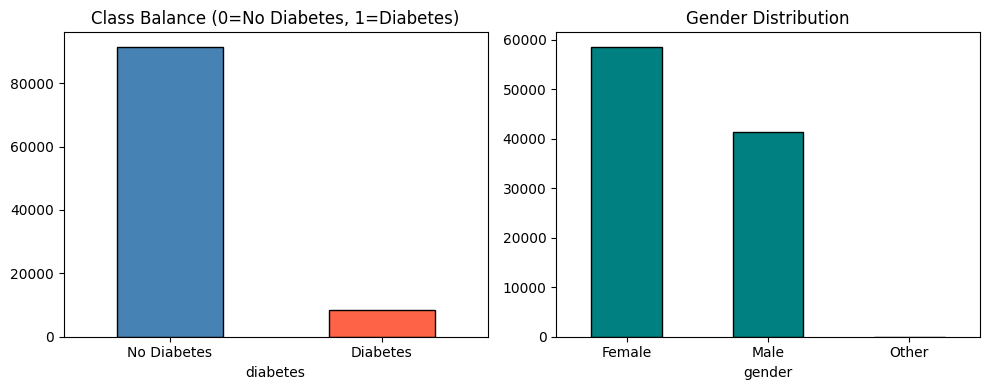

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Class balance
df['diabetes'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Class Balance (0=No Diabetes, 1=Diabetes)')
axes[0].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)

# Gender distribution
df['gender'].value_counts().plot(kind='bar', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title('Gender Distribution')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 1.3 Distributions of Numeric Features

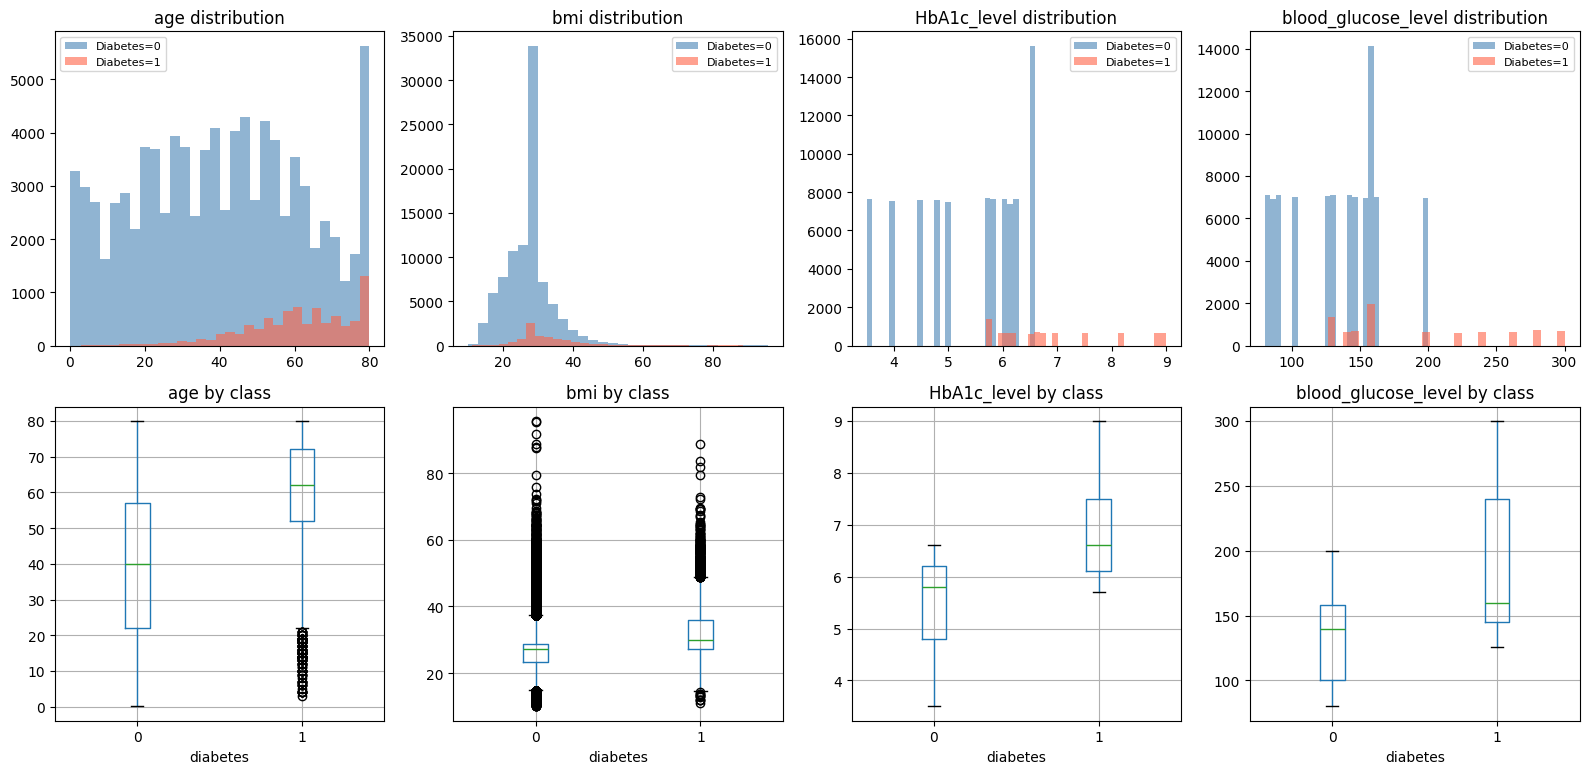

In [7]:
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, col in enumerate(num_cols):
    # Histogram by class
    for label, color in zip([0, 1], ['steelblue', 'tomato']):
        axes[0][i].hist(df[df['diabetes']==label][col], bins=30, alpha=0.6, color=color, label=f'Diabetes={label}')
    axes[0][i].set_title(f'{col} distribution')
    axes[0][i].legend(fontsize=8)

    # Boxplot
    df.boxplot(column=col, by='diabetes', ax=axes[1][i])
    axes[1][i].set_title(f'{col} by class')

plt.suptitle('')
plt.tight_layout()
plt.show()

### 1.4 Correlation Heatmap

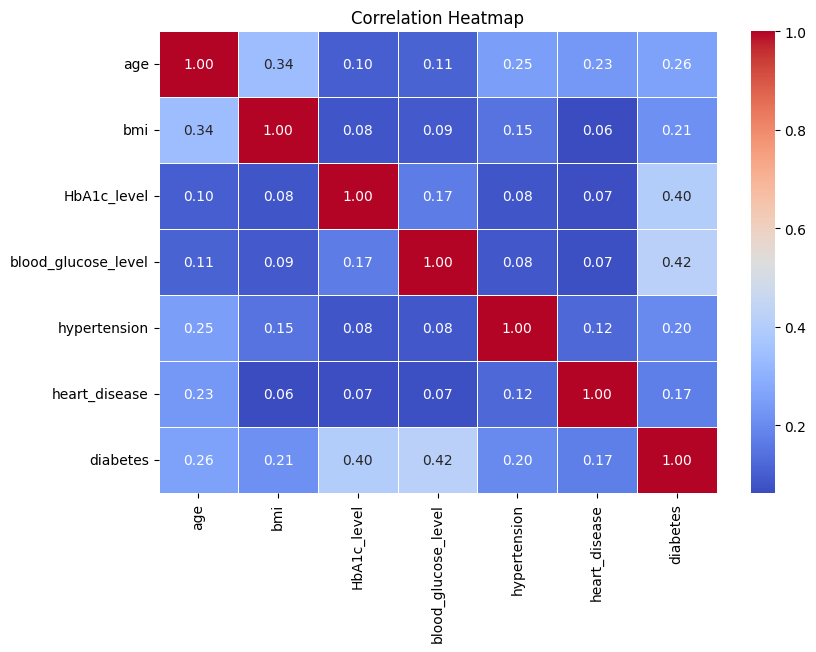

In [8]:
plt.figure(figsize=(9, 6))
sns.heatmap(
    df[num_cols + ['hypertension', 'heart_disease', 'diabetes']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.show()

### 1.5 Preprocessing

In [9]:
df_proc = df.copy()

# ── Drop 'Other' gender (only 18 rows — too few to be meaningful)
df_proc = df_proc[df_proc['gender'] != 'Other'].reset_index(drop=True)

# ── Encode gender: Female=0, Male=1
df_proc['gender'] = LabelEncoder().fit_transform(df_proc['gender'])

# ── Encode smoking_history with ordinal logic
smoking_map = {
    'No Info': 0,
    'never': 1,
    'not current': 2,
    'ever': 3,
    'former': 4,
    'current': 5
}
df_proc['smoking_history'] = df_proc['smoking_history'].map(smoking_map)

print('Preprocessing done ✅')
print(df_proc.dtypes)
df_proc.head()

Preprocessing done ✅
gender                   int64
age                    float64
hypertension             int64
heart_disease            int64
smoking_history          int64
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,1,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,1,27.32,5.7,158,0
3,0,36.0,0,0,5,23.45,5.0,155,0
4,1,76.0,1,1,5,20.14,4.8,155,0


### 1.6 Feature Engineering

In [10]:
# ── New features based on domain knowledge ──────────────────────────

# BMI categories (WHO standard)
df_proc['bmi_category'] = pd.cut(
    df_proc['bmi'],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=[0, 1, 2, 3]  # Underweight, Normal, Overweight, Obese
).astype(int)

# Age groups
df_proc['age_group'] = pd.cut(
    df_proc['age'],
    bins=[0, 30, 45, 60, 100],
    labels=[0, 1, 2, 3]  # Young, Middle, Senior, Elderly
).astype(int)

# Risk score: sum of known risk factors
df_proc['risk_score'] = (
    df_proc['hypertension'] +
    df_proc['heart_disease'] +
    (df_proc['bmi'] > 30).astype(int) +
    (df_proc['HbA1c_level'] >= 5.7).astype(int) +
    (df_proc['blood_glucose_level'] >= 126).astype(int)
)

# Interaction: age × bmi
df_proc['age_bmi'] = df_proc['age'] * df_proc['bmi']

print('New features added:', ['bmi_category', 'age_group', 'risk_score', 'age_bmi'])
df_proc.head()

New features added: ['bmi_category', 'age_group', 'risk_score', 'age_bmi']


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,bmi_category,age_group,risk_score,age_bmi
0,0,80.0,0,1,1,25.19,6.6,140,0,2,3,3,2015.20
1,0,54.0,0,0,0,27.32,6.6,80,0,2,2,1,1475.28
2,1,28.0,0,0,1,27.32,5.7,158,0,2,0,2,764.96
3,0,36.0,0,0,5,23.45,5.0,155,0,1,1,1,844.20
4,1,76.0,1,1,5,20.14,4.8,155,0,1,3,3,1530.64


### 1.7 Mutual Information — Feature Importance

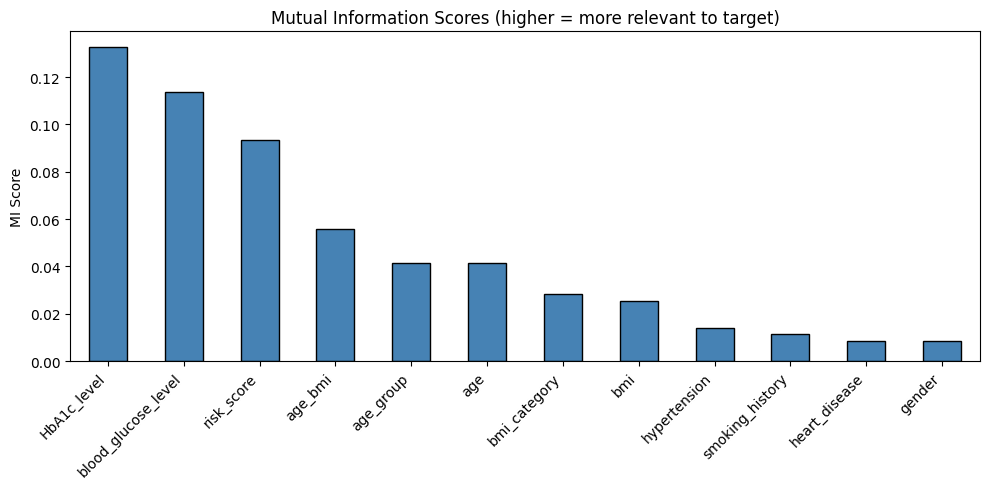

HbA1c_level            0.132723
blood_glucose_level    0.113515
risk_score             0.093617
age_bmi                0.055694
age_group              0.041349
age                    0.041256
bmi_category           0.028494
bmi                    0.025449
hypertension           0.013865
smoking_history        0.011425
heart_disease          0.008438
gender                 0.008365
dtype: float64


In [11]:
X_all = df_proc.drop('diabetes', axis=1)
y_all = df_proc['diabetes']

mi_scores = mutual_info_classif(X_all, y_all, random_state=42)
mi_series = pd.Series(mi_scores, index=X_all.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
mi_series.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Mutual Information Scores (higher = more relevant to target)')
plt.ylabel('MI Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(mi_series)

In [13]:
# ── Keep features with MI > 0.01 (drop very low-info features) ──────
selected_features = mi_series[mi_series > 0.01].index.tolist()
print(f'Selected {len(selected_features)} features:', selected_features)

X = df_proc[selected_features]
y = df_proc['diabetes']

Selected 10 features: ['HbA1c_level', 'blood_glucose_level', 'risk_score', 'age_bmi', 'age_group', 'age', 'bmi_category', 'bmi', 'hypertension', 'smoking_history']


In [15]:
X.shape

(99982, 10)

### 1.8 Train / Validation / Test Split

In [16]:
# 70% train | 15% val | 15% test  (stratified to preserve class ratio)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)  # 0.176 of 0.85 ≈ 0.15 of total

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')

# Scale numeric features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit ONLY on train
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

Train: 70026 | Val: 14958 | Test: 14998


---
## Task 02 — Model Selection: LR vs RF vs XGBoost

### 2.1 Cross-Validation (5-Fold Stratified)

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scoring = ['accuracy', 'roc_auc', 'f1', 'precision', 'recall']

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0)
}

cv_results = {}
for name, model in models.items():
    scores = cross_validate(model, X_train_s, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1)
    cv_results[name] = {
        'Accuracy':  scores['test_accuracy'].mean(),
        'ROC-AUC':   scores['test_roc_auc'].mean(),
        'F1':        scores['test_f1'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall':    scores['test_recall'].mean(),
    }
    print(f"{name}: AUC={cv_results[name]['ROC-AUC']:.4f} | F1={cv_results[name]['F1']:.4f}")

cv_df = pd.DataFrame(cv_results).T
print('\n--- 5-Fold CV Summary ---')
cv_df

Logistic Regression: AUC=0.9635 | F1=0.7246
Random Forest: AUC=0.9629 | F1=0.7940
XGBoost: AUC=0.9763 | F1=0.8038

--- 5-Fold CV Summary ---


,Accuracy,ROC-AUC,F1,Precision,Recall
Logistic Regression,0.959486,0.963458,0.724621,0.858238,0.627081
Random Forest,0.969597,0.962904,0.794017,0.936222,0.689400
XGBoost,0.971168,0.976318,0.803777,0.953522,0.694775


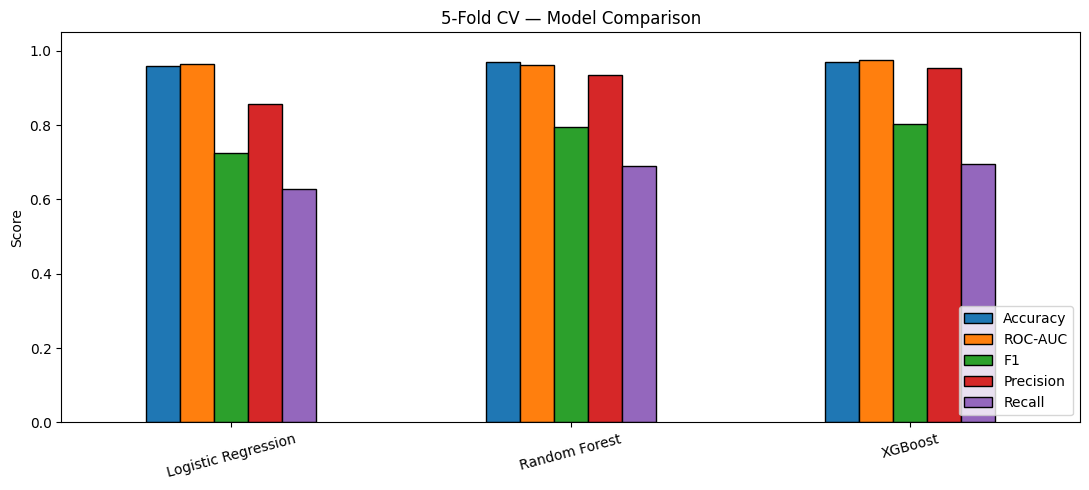

In [18]:
cv_df.plot(kind='bar', figsize=(11, 5), edgecolor='black')
plt.title('5-Fold CV — Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 2.2 Evaluate on Held-Out Validation Set

In [19]:
val_results = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred  = model.predict(X_val_s)
    y_proba = model.predict_proba(X_val_s)[:, 1]

    val_results[name] = {
        'Accuracy':  accuracy_score(y_val, y_pred),
        'ROC-AUC':   roc_auc_score(y_val, y_proba),
        'F1':        f1_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall':    recall_score(y_val, y_pred),
    }
    print(f"\n{name}")
    print(classification_report(y_val, y_pred, target_names=['No Diabetes', 'Diabetes']))

val_df = pd.DataFrame(val_results).T
print('\n--- Validation Set Summary ---')
val_df


Logistic Regression
              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     13686
    Diabetes       0.87      0.64      0.74      1272

    accuracy                           0.96     14958
   macro avg       0.92      0.82      0.86     14958
weighted avg       0.96      0.96      0.96     14958


Random Forest
              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     13686
    Diabetes       0.93      0.69      0.79      1272

    accuracy                           0.97     14958
   macro avg       0.95      0.84      0.89     14958
weighted avg       0.97      0.97      0.97     14958


XGBoost
              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     13686
    Diabetes       0.96      0.69      0.80      1272

    accuracy                           0.97     14958
   macro avg       0.96      0.85      0.89     14958
weighted avg       0.97      

,Accuracy,ROC-AUC,F1,Precision,Recall
Logistic Regression,0.961358,0.964659,0.737987,0.871520,0.639937
Random Forest,0.968980,0.963489,0.790425,0.928875,0.687893
XGBoost,0.971253,0.976835,0.804011,0.956616,0.693396


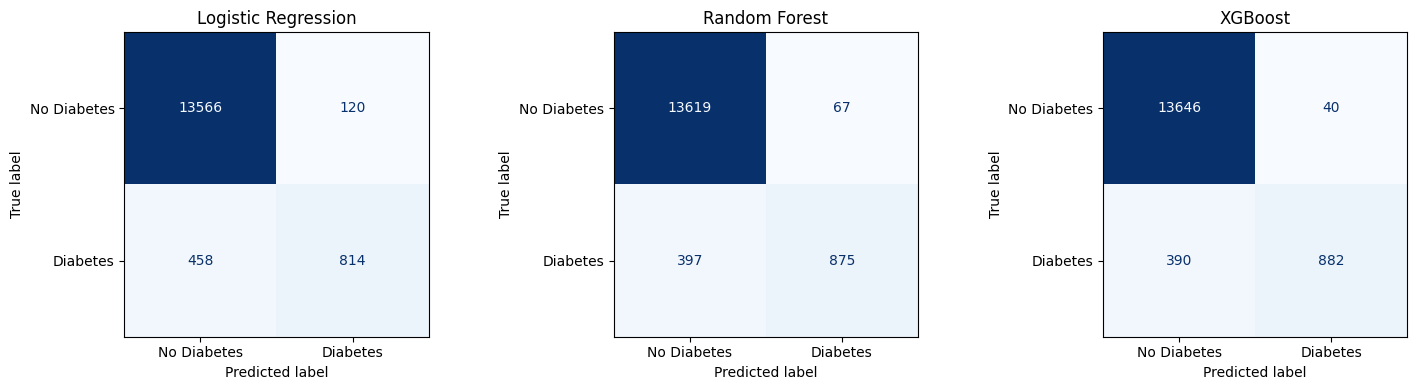

In [20]:
# Confusion matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_val_s)
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.show()

### 2.3 Select Best Model

In [21]:
best_model_name = val_df['ROC-AUC'].idxmax()
best_model = models[best_model_name]
print(f'✅ Best model by ROC-AUC: {best_model_name}')
val_df

✅ Best model by ROC-AUC: XGBoost


,Accuracy,ROC-AUC,F1,Precision,Recall
Logistic Regression,0.961358,0.964659,0.737987,0.871520,0.639937
Random Forest,0.968980,0.963489,0.790425,0.928875,0.687893
XGBoost,0.971253,0.976835,0.804011,0.956616,0.693396


### 2.4 Final Evaluation on Test Set (Best Model Only)

In [22]:
y_test_pred  = best_model.predict(X_test_s)
y_test_proba = best_model.predict_proba(X_test_s)[:, 1]

print(f'=== TEST SET RESULTS: {best_model_name} ===')
print(f"Accuracy  : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_test_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_test_pred):.4f}")
print()
print(classification_report(y_test, y_test_pred, target_names=['No Diabetes', 'Diabetes']))

=== TEST SET RESULTS: XGBoost ===
Accuracy  : 0.9699
ROC-AUC   : 0.9756
F1-Score  : 0.7968
Precision : 0.9336
Recall    : 0.6949

              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     13723
    Diabetes       0.93      0.69      0.80      1275

    accuracy                           0.97     14998
   macro avg       0.95      0.85      0.89     14998
weighted avg       0.97      0.97      0.97     14998



---
## Task 03 — MLflow Experiments

### 3.1 Setup MLflow

In [23]:
mlflow.set_tracking_uri('mlruns')        # local folder
mlflow.set_experiment('diabetes_prediction')
print('MLflow experiment set ✅')

2026/04/30 16:37:13 INFO mlflow.tracking.fluent: Experiment with name 'diabetes_prediction' does not exist. Creating a new experiment.


MLflow experiment set ✅


### 3.2 Log All 3 Models as Separate Runs

In [24]:
# Model configs to experiment with
experiment_configs = [
    {
        'name': 'Logistic Regression',
        'model': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
        'params': {'C': 1.0, 'max_iter': 1000, 'solver': 'lbfgs'}
    },
    {
        'name': 'Random Forest',
        'model': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
        'params': {'n_estimators': 100, 'max_depth': 10}
    },
    {
        'name': 'XGBoost',
        'model': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                               random_state=42, eval_metric='logloss', verbosity=0),
        'params': {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 6}
    },
]

for cfg in experiment_configs:
    with mlflow.start_run(run_name=cfg['name']):

        # ── Log parameters
        mlflow.log_params(cfg['params'])
        mlflow.log_param('n_features', len(selected_features))
        mlflow.log_param('train_size', X_train.shape[0])

        # ── Train
        cfg['model'].fit(X_train_s, y_train)

        # ── Predict on val
        y_pred  = cfg['model'].predict(X_val_s)
        y_proba = cfg['model'].predict_proba(X_val_s)[:, 1]

        # ── Log metrics
        metrics = {
            'val_accuracy':  accuracy_score(y_val, y_pred),
            'val_roc_auc':   roc_auc_score(y_val, y_proba),
            'val_f1':        f1_score(y_val, y_pred),
            'val_precision': precision_score(y_val, y_pred),
            'val_recall':    recall_score(y_val, y_pred),
        }
        mlflow.log_metrics(metrics)

        # ── Log model artifact
        if cfg['name'] == 'XGBoost':
            mlflow.xgboost.log_model(cfg['model'], 'model')
        else:
            mlflow.sklearn.log_model(cfg['model'], 'model')

        print(f"{cfg['name']:25s} | AUC: {metrics['val_roc_auc']:.4f} | F1: {metrics['val_f1']:.4f} | Logged ✅")

print('\nAll runs logged to MLflow!')

2026/04/30 16:38:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 16:38:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression       | AUC: 0.9647 | F1: 0.7380 | Logged ✅


2026/04/30 16:38:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 16:38:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest             | AUC: 0.9758 | F1: 0.8037 | Logged ✅


2026/04/30 16:38:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost                   | AUC: 0.9794 | F1: 0.8041 | Logged ✅

All runs logged to MLflow!


### 3.3 Hyperparameter Experiment — XGBoost (multiple runs)

In [25]:
# Try different learning rates for XGBoost
for lr in [0.01, 0.05, 0.1, 0.3]:
    with mlflow.start_run(run_name=f'XGBoost_lr_{lr}'):

        params = {'n_estimators': 100, 'learning_rate': lr, 'max_depth': 6}
        mlflow.log_params(params)

        model = XGBClassifier(**params, random_state=42,
                              eval_metric='logloss', verbosity=0)
        model.fit(X_train_s, y_train)

        y_pred  = model.predict(X_val_s)
        y_proba = model.predict_proba(X_val_s)[:, 1]

        metrics = {
            'val_roc_auc': roc_auc_score(y_val, y_proba),
            'val_f1':      f1_score(y_val, y_pred),
        }
        mlflow.log_metrics(metrics)
        mlflow.xgboost.log_model(model, 'model')

        print(f"lr={lr} | AUC: {metrics['val_roc_auc']:.4f} | F1: {metrics['val_f1']:.4f}")

2026/04/30 16:39:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


lr=0.01 | AUC: 0.9731 | F1: 0.8028


2026/04/30 16:39:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


lr=0.05 | AUC: 0.9783 | F1: 0.8032


2026/04/30 16:39:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


lr=0.1 | AUC: 0.9794 | F1: 0.8041


2026/04/30 16:39:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


lr=0.3 | AUC: 0.9768 | F1: 0.8040


### 3.4 Compare Runs Programmatically

In [26]:
experiment = mlflow.get_experiment_by_name('diabetes_prediction')
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=['metrics.val_roc_auc DESC']
)

display_cols = ['tags.mlflow.runName', 'metrics.val_roc_auc',
                'metrics.val_f1', 'metrics.val_accuracy']

display_cols = [c for c in display_cols if c in runs_df.columns]
print(runs_df[display_cols].to_string(index=False))

tags.mlflow.runName  metrics.val_roc_auc  metrics.val_f1  metrics.val_accuracy
     XGBoost_lr_0.1             0.979424        0.804095                   NaN
            XGBoost             0.979424        0.804095              0.971855
    XGBoost_lr_0.05             0.978338        0.803187                   NaN
     XGBoost_lr_0.3             0.976835        0.804011                   NaN
      Random Forest             0.975782        0.803738              0.971921
    XGBoost_lr_0.01             0.973086        0.802824                   NaN
Logistic Regression             0.964659        0.737987              0.961358


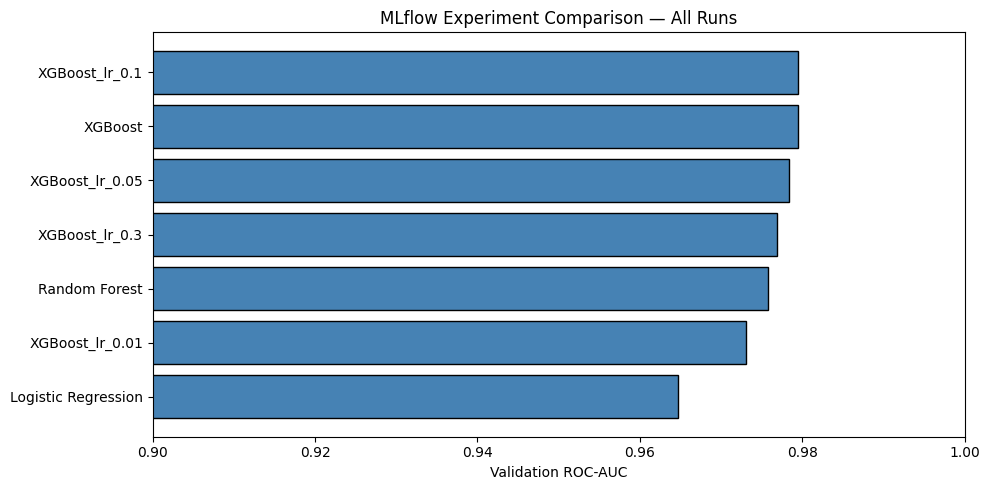

In [27]:
# Bar chart of all runs by AUC
subset = runs_df[['tags.mlflow.runName', 'metrics.val_roc_auc']].dropna()
subset = subset.sort_values('metrics.val_roc_auc', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(subset['tags.mlflow.runName'], subset['metrics.val_roc_auc'],
         color='steelblue', edgecolor='black')
plt.xlabel('Validation ROC-AUC')
plt.title('MLflow Experiment Comparison — All Runs')
plt.xlim(0.9, 1.0)
plt.tight_layout()
plt.show()

### 3.5 Load Best Run's Model from MLflow & Final Test

In [28]:
best_run = runs_df.iloc[0]
best_run_id = best_run['run_id']
best_run_name = best_run['tags.mlflow.runName']

print(f'Best run: {best_run_name} (ID: {best_run_id})')

# Load model
model_uri = f'runs:/{best_run_id}/model'
loaded_model = mlflow.pyfunc.load_model(model_uri)

# Test prediction
y_final_pred = loaded_model.predict(pd.DataFrame(X_test_s, columns=selected_features))

print(f'\n=== FINAL TEST RESULTS ({best_run_name}) ===')
print(f'Accuracy  : {accuracy_score(y_test, y_final_pred):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_final_pred):.4f}')
print()
print(classification_report(y_test, y_final_pred, target_names=['No Diabetes', 'Diabetes']))

Best run: XGBoost_lr_0.1 (ID: 45eb880cc7224076b7e7f044b3421de6)

=== FINAL TEST RESULTS (XGBoost_lr_0.1) ===
Accuracy  : 0.9719
F1-Score  : 0.8052

              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     13723
    Diabetes       0.98      0.68      0.81      1275

    accuracy                           0.97     14998
   macro avg       0.98      0.84      0.90     14998
weighted avg       0.97      0.97      0.97     14998



---
## 📌 Summary

| Task | Done |
|------|------|
| EDA (distributions, class balance, correlations) | ✅ |
| Preprocessing (encoding, scaling) | ✅ |
| Feature Engineering (BMI cat, age group, risk score, interaction) | ✅ |
| Mutual Information feature selection | ✅ |
| 5-Fold Stratified Cross-Validation | ✅ |
| Model selection: LR vs RF vs XGBoost | ✅ |
| Evaluation metrics (Accuracy, AUC, F1, Precision, Recall) | ✅ |
| MLflow experiment tracking + hyperparameter sweep | ✅ |
| Load best model from MLflow and final test evaluation | ✅ |

In [31]:
import joblib

# Export the full inference bundle so the API can reproduce notebook preprocessing
inference_bundle = {
    'model': best_model,
    'scaler': scaler,
    'selected_features': selected_features,
    'feature_columns': list(X.columns),
}

joblib.dump(inference_bundle, 'best_diabetes_model.pkl')
print('✅ Inference bundle exported successfully as best_diabetes_model.pkl')

✅ Inference bundle exported successfully as best_diabetes_model.pkl


## Register the Best Model in MLflow

In [34]:
model_name = 'XGB-lr-0.1'
run_id = input('Please type RunID (leave blank to use best_run_id): ').strip() 

# correct artifact path used when logging models earlier was 'model'
model_uri = f"runs:/{run_id}/model"

registered = mlflow.register_model(model_uri=model_uri, name=model_name)
print(f"Registered model: {registered.name} | version: {registered.version} | run_id: {registered.run_id}")

Successfully registered model 'XGB-lr-0.1'.
2026/04/30 19:50:20 WARNING mlflow.tracking._model_registry.fluent: Run with id 45eb880cc7224076b7e7f044b3421de6 has no artifacts at artifact path 'model', registering model based on models:/m-567203c0ebeb42f3bef81912042978cd instead


Registered model: XGB-lr-0.1 | version: 1 | run_id: 45eb880cc7224076b7e7f044b3421de6


Created version '1' of model 'XGB-lr-0.1'.
